In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
import pickle


In [6]:
# Load Dataset
data = pd.read_csv("/content/amazon_alexa.csv")
data

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1


In [10]:
import re

# Preprocess Text Data
def preprocess_text(text):
    # Ensure the input is a string (handling NaN or non-string types)
    if isinstance(text, str):  # Only process text if it's a string
        text = re.sub(r'\W', ' ', text)  # Remove non-word characters
        text = text.lower()  # Convert to lowercase
        text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
        return text
    else:
        return ''  # Return an empty string if the value is not a string (e.g., NaN or numbers)

# Apply preprocessing to the 'verified_reviews' column
data['Processed_Review'] = data['verified_reviews'].apply(preprocess_text)



In [12]:

# Feature Extraction
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['Processed_Review'])
y = data['feedback']  # Sentiment labels (positive/negative)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Save the trained model and vectorizer
with open('model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)
with open('vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)


In [17]:
import pickle

# Load the saved model and vectorizer
with open('model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

with open('vectorizer.pkl', 'rb') as vectorizer_file:
    loaded_vectorizer = pickle.load(vectorizer_file)

# Predict Sentiment for a new review
def predict_sentiment(review):
    processed = preprocess_text(review)
    vector = loaded_vectorizer.transform([processed])
    prediction = loaded_model.predict(vector)
    return 'Positive' if prediction[0] == 1 else 'Negative'

# Test Example
test_review = "I love the sound quality of this Alexa!"
print("Review:", test_review)
print("Sentiment:", predict_sentiment(test_review))


Review: I love the sound quality of this Alexa!
Sentiment: Positive


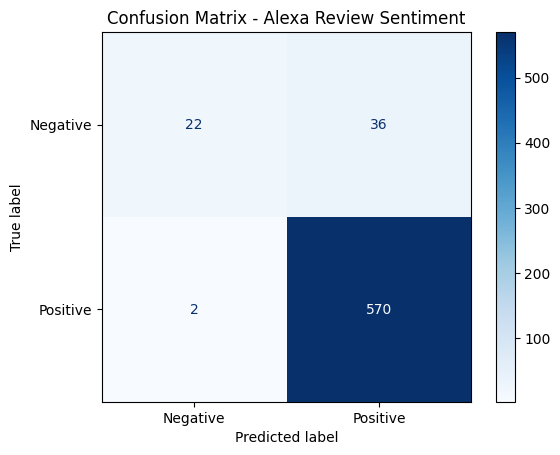

Model Accuracy: 93.97%


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

# Predictions on test set
y_pred = loaded_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Alexa Review Sentiment")
plt.show()

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%")
